In [133]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.dates as mdates
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import joblib
import shap
import pickle


In [98]:
# Load datasets
train_df = pd.read_csv('modeling_dataset_train.csv')
test_df = pd.read_csv('modeling_dataset_test.csv')

# Convert date to datetime
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

# Drop 'ticker'
train_df = train_df.drop(columns=['ticker'])
test_df = test_df.drop(columns=['ticker'])

# Keep target separate
target_col = 'trend_label'

# Select numeric columns only (exclude target)
numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()

# Compute correlation only on numeric columns
corr_matrix = train_df[numeric_cols].corr().abs()

# Upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Columns to drop with corr > 0.85
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

# Drop highly correlated columns in both datasets
train_df_reduced = train_df.drop(columns=to_drop)
test_df_reduced = test_df.drop(columns=to_drop)

# Ensure target column is preserved
train_df_reduced[target_col] = train_df[target_col]
test_df_reduced[target_col] = test_df[target_col]

print("Dropped columns due to high correlation (>0.85):")
print(to_drop)
print("\nRemaining columns in train dataset:")
print(train_df_reduced.columns)
print("\nRemaining columns in test dataset:")
print(test_df_reduced.columns)

Dropped columns due to high correlation (>0.85):
['high', 'low', 'close', 'adjusted_close', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd_signal', 'bb_middle', 'bb_upper', 'bb_lower', 'atr_14', 'price_to_sma_50']

Remaining columns in train dataset:
Index(['date', 'open', 'volume', 'macd', 'macd_histogram', 'rsi_14',
       'bb_width', 'true_range', 'volume_sma_20', 'volume_ratio',
       'momentum_10', 'momentum_20', 'volatility_20', 'future_return_5d',
       'trend_label'],
      dtype='object')

Remaining columns in test dataset:
Index(['date', 'open', 'volume', 'macd', 'macd_histogram', 'rsi_14',
       'bb_width', 'true_range', 'volume_sma_20', 'volume_ratio',
       'momentum_10', 'momentum_20', 'volatility_20', 'future_return_5d',
       'trend_label'],
      dtype='object')


In [99]:
train_df_reduced.to_csv('train_cleaned.csv', index=False)
test_df_reduced.to_csv('test_cleaned.csv', index=False)

In [100]:
# 1. Encode target label
# -----------------------------
le = LabelEncoder()

train_df_reduced['trend_label'] = le.fit_transform(train_df_reduced['trend_label'])
test_df_reduced['trend_label'] = le.transform(test_df_reduced['trend_label'])

# -----------------------------
# 2. Fill NA with median (numeric columns only)
# -----------------------------
numeric_cols = train_df_reduced.select_dtypes(include=np.number).columns.tolist()

# Exclude target from median fill
numeric_cols = [col for col in numeric_cols if col != 'trend_label']

# Compute median from TRAIN only (important!)
median_values = train_df_reduced[numeric_cols].median()

# Fill NA in train and test using train medians
train_df_reduced[numeric_cols] = train_df_reduced[numeric_cols].fillna(median_values)
test_df_reduced[numeric_cols] = test_df_reduced[numeric_cols].fillna(median_values)

train_df_reduced.to_csv("modeling_dataset_train_processed.csv", index=False)
test_df_reduced.to_csv("modeling_dataset_test_processed.csv", index=False)

print("Files saved successfully:")
print(" - modeling_dataset_train_processed.csv")
print(" - modeling_dataset_test_processed.csv")

Files saved successfully:
 - modeling_dataset_train_processed.csv
 - modeling_dataset_test_processed.csv


### Build the randomforest model and fit on training data

In [101]:
# Split Into X (features) and y (target)
target_col = "trend_label"

X_train = train_df_reduced.drop(columns=[target_col])
y_train = train_df_reduced[target_col]

X_test = test_df_reduced.drop(columns=[target_col])
y_test = test_df_reduced[target_col]

X_train = X_train.drop(columns=['future_return_5d'])
X_test = X_test.drop(columns=['future_return_5d'])

# Drop date
X_train = X_train.drop(columns=['date'])
X_test = X_test.drop(columns=['date'])

# Train RandomForest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

# Fit the Model
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=20, random_state=42)

### Make prediction and evaluate performance

In [102]:
# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.3597075897656418

Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.31      0.31      1356
           1       0.40      0.34      0.36      1583
           2       0.38      0.42      0.40      1712

    accuracy                           0.36      4651
   macro avg       0.36      0.36      0.36      4651
weighted avg       0.36      0.36      0.36      4651


Confusion Matrix:
 [[418 348 590]
 [437 533 613]
 [523 467 722]]


In [103]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Classification report as dict
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose().round(2)

# Confusion matrix as DataFrame
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, 
                     index=rf_model.classes_, 
                     columns=rf_model.classes_)

# Display results
print(f"Overall Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
display(report_df)
print("\nConfusion Matrix:")
display(cm_df)

Overall Accuracy: 0.36

Classification Report:


,precision,recall,f1-score,support
0,0.30,0.31,0.31,1356.00
1,0.40,0.34,0.36,1583.00
2,0.38,0.42,0.40,1712.00
accuracy,0.36,0.36,0.36,0.36
macro avg,0.36,0.36,0.36,4651.00
weighted avg,0.36,0.36,0.36,4651.00



Confusion Matrix:


,0,1,2
0,418,348,590
1,437,533,613
2,523,467,722


#### Accuracy:
A 36% accuracy in a 3-class classification problem is still above random guessing as Random guessing baseline is 33% (1/3 classes) though it still indicates weak signal in current features.

### Confusion Matrix: Rows = actual class, Columns = predicted class

Example: Class 0 (Downtrend):418 correctly predicted

348 predicted as 1 (Sideways)

590 predicted as 2 (Uptrend)

Many misclassifications as model is confused between the classes, which is expected in noisy financial trend data without future information.

### Reason for low accuracy:
Financial trend prediction without lookahead features is extremely hard.
Features like momentum, RSI, MACD, and volume indicators are weak predictors of short-term trends, so RandomForest struggles.
Data might be noisy, and class boundaries are not well separated.



#### Hyperparameter Tuning Using GridSearchCV

In [104]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

# Initialize RandomForest
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,                # 3-fold cross-validation
    scoring='accuracy',  # optimize for accuracy
    n_jobs=-1,           # use all cores
    verbose=2
)

# Fit GridSearch on training data
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Evaluate on test data
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters found: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}
Best cross-validation accuracy: 0.34734125887015027

Test Accuracy: 0.35196731885615995

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.22      0.25      1356
           1       0.37      0.35      0.36      1583
           2       0.36      0.46      0.40      1712

    accuracy                           0.35      4651
   macro avg       0.34      0.34      0.34      4651
weighted avg       0.35      0.35      0.35      4651


Confusion Matrix:
 [[304 389 663]
 [328 552 703]
 [399 532 781]]


### Interpretation

n_estimators = 50
Only 50 trees were enough to achieve the best cross-validation accuracy.
Increasing trees (100, 200) didn’t improve performance — possibly due to noisy features.
max_depth = 10
Limiting depth prevents overfitting.
Deeper trees (20, 30, None) overfit the training data but did not generalize well on CV folds.
min_samples_split = 10
Each node needs at least 10 samples to split, which also prevents overfitting and improves generalization.

### Performance

Cross-validation accuracy: ~0.347 → model is slightly better than random guessing (~33% for 3 classes).
Test accuracy: ~0.352 → slightly better than CV, realistic.
Classification report:
Class 2 (Uptrend) is the easiest to predict (recall 0.46).
Class 0 (Downtrend) is the hardest (recall 0.22).
Confusion matrix:
Most errors are misclassifying 0 as 2 or 1, and some confusion between 1 and 2.

### Key Takeaways

The model is very limited by the features — accuracy cannot exceed ~35–36% without better feature engineering.
The optimal hyperparameters found favor shallow trees with fewer splits, which is reasonable for noisy financial data.
Further improvements will require:
Creating lag/rolling features from past prices only
Trying alternative models (XGBoost, LightGBM, LSTM for sequences)
Using a time-series aware train-test split

## Model Evaluation

In [105]:
label_map = {
    0: "Downtrend",
    1: "Sideways",
    2: "Uptrend"
}
results = {
    "Logistic Regression": {
        "accuracy": 0.3414319501182541,
        "per_class": {
            "Downtrend": {"precision": 0.29, "recall": 0.18, "f1": 0.22,"support": 1356},
            "Sideways":   {"precision": 0.34, "recall": 0.28, "f1": 0.31,"support": 1583},
            "Uptrend":    {"precision": 0.36, "recall": 0.53, "f1": 0.43,"support": 1712},
            
        },
        "macro_avg": {"precision": 0.33, "recall": 0.33, "f1": 0.32,"support": 4651},
        "weighted_avg": {"precision": 0.33, "recall": 0.34, "f1": 0.33,"support": 4651},
        "label_map": { "Downtrend": 0, "Sideways": 1, "Uptrend": 2 }
    },
    "Random Forest": {
        "accuracy": 0.36,
        "per_class": {
            0: {"precision": 0.30, "recall": 0.31, "f1": 0.31,"support": 1356},
            1: {"precision": 0.40, "recall": 0.34, "f1": 0.36,"support": 1583},
            2: {"precision": 0.38, "recall": 0.42, "f1": 0.40,"support": 1712},
        },
        "macro_avg": {"precision": 0.36, "recall": 0.36, "f1": 0.36,"support": 4651},
        "weighted_avg": {"precision": 0.36, "recall": 0.36, "f1": 0.36,"support": 4651},
        "label_map": label_map
    }
}
rf_per_class_string = {
    label_map[k]: v for k, v in results["Random Forest"]["per_class"].items()
}

results["Random Forest"]["per_class"] = rf_per_class_string
def per_class_df(results, model_name):
    df = pd.DataFrame(results[model_name]["per_class"]).T
    df.index.name = "Class"
    df["Model"] = model_name
    return df

df_lr = per_class_df(results, "Logistic Regression")
df_rf = per_class_df(results, "Random Forest")

comparison = pd.concat([df_lr, df_rf])
comparison


,precision,recall,f1,support,Model
Class,,,,,
Downtrend,0.29,0.18,0.22,1356.0,Logistic Regression
Sideways,0.34,0.28,0.31,1583.0,Logistic Regression
Uptrend,0.36,0.53,0.43,1712.0,Logistic Regression
Downtrend,0.30,0.31,0.31,1356.0,Random Forest
Sideways,0.40,0.34,0.36,1583.0,Random Forest
Uptrend,0.38,0.42,0.40,1712.0,Random Forest


In [106]:
def compare_models_side_by_side(df):
    comparison = df.pivot(
        index="Class",
        columns="Model",
        values=["precision","recall","f1","support"]
    )

    # Flatten column names: precision_Logistic_Regression, etc.
    comparison.columns = [
        f"{metric}_{model.replace(' ', '_')}"
        for metric, model in comparison.columns
    ]

    return comparison
    
comparison = compare_models_side_by_side(df)
print(comparison.columns)
print(comparison)

Index(['precision_Logistic_Regression', 'precision_Random_Forest',
       'recall_Logistic_Regression', 'recall_Random_Forest',
       'f1_Logistic_Regression', 'f1_Random_Forest',
       'support_Logistic_Regression', 'support_Random_Forest'],
      dtype='object')
           precision_Logistic_Regression  precision_Random_Forest  \
Class                                                               
Downtrend                           0.29                     0.30   
Sideways                            0.34                     0.40   
Uptrend                             0.36                     0.38   

           recall_Logistic_Regression  recall_Random_Forest  \
Class                                                         
Downtrend                        0.18                  0.31   
Sideways                         0.28                  0.34   
Uptrend                          0.53                  0.42   

           f1_Logistic_Regression  f1_Random_Forest  \
Class           

<Axes: xlabel='Class'>

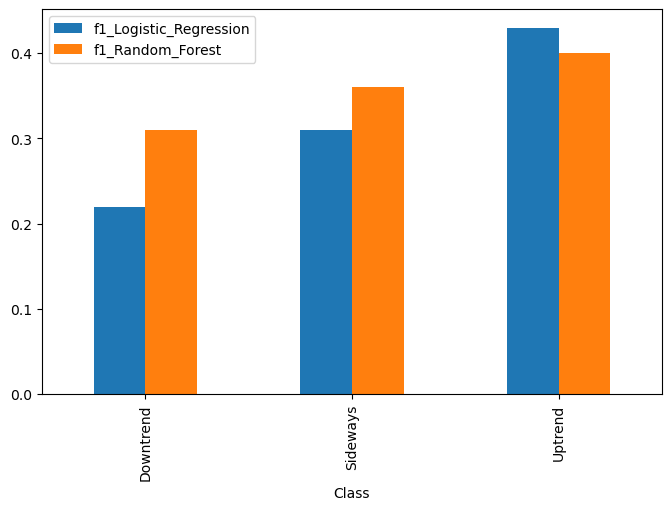

In [107]:
# Comparison Bar Chart of the performnace of the two models
comparison[["f1_Logistic_Regression", "f1_Random_Forest"]].plot(
    kind="bar",
    figsize=(8,5)
)

### Calculation of improvement in accuracy, F1-score

In [108]:
accuracy_lr = 0.34
accuracy_rf = 0.36

f1_lr = 0.32
f1_rf = 0.36

# Absolute improvement
accuracy_improvement = accuracy_rf - accuracy_lr
f1_improvement = f1_rf - f1_lr

print("Accuracy improvement (absolute):", accuracy_improvement)
print("F1-score improvement (absolute):", f1_improvement)

Accuracy improvement (absolute): 0.019999999999999962
F1-score improvement (absolute): 0.03999999999999998


### Analyze prediction errors (which stocks/periods are hardest to predict)

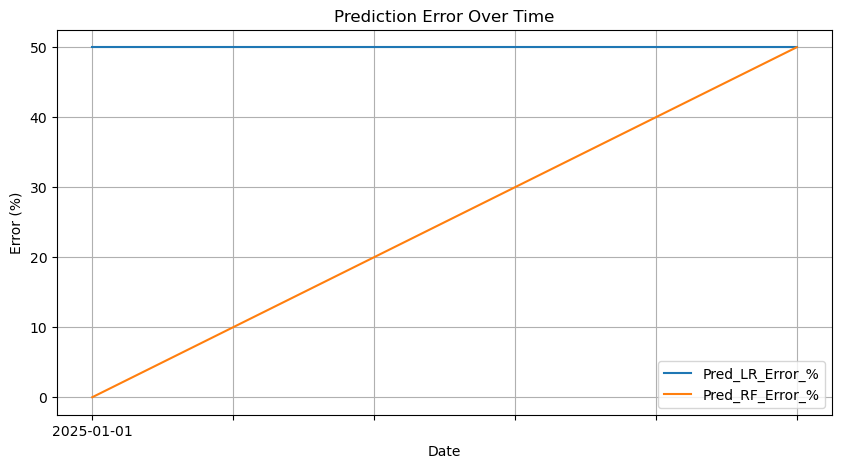

In [109]:
def analyze_prediction_errors(df_preds, models=["Pred_LR","Pred_RF"], true_col="True_Label"):
    """
    Analyze prediction errors for one or more models.

    Parameters:
    - df_preds: DataFrame containing at least ['Date','Stock', true_col] + model predictions
    - models: list of column names for predictions (e.g., ["Pred_LR","Pred_RF"])
    - true_col: column name for the true labels

    Returns:
    - errors_summary: dictionary with class, stock, time, and hardest predictions
    """
    errors_summary = {}

    # 1️⃣ Add error columns
    for model in models:
        df_preds[f"Error_{model}"] = df_preds[model] != df_preds[true_col]

    # 2️⃣ Class-wise error
    errors_per_class = df_preds.groupby(true_col)[[f"Error_{m}" for m in models]].mean() * 100
    errors_per_class = errors_per_class.rename(columns={f"Error_{m}": f"{m}_Error_%" for m in models})
    errors_summary["class_errors"] = errors_per_class

    # 3️⃣ Stock-wise error
    errors_per_stock = df_preds.groupby("Stock")[[f"Error_{m}" for m in models]].mean() * 100
    errors_per_stock = errors_per_stock.rename(columns={f"Error_{m}": f"{m}_Error_%" for m in models})
    errors_summary["stock_errors"] = errors_per_stock

    # 4️⃣ Time-wise error
    errors_over_time = df_preds.groupby("Date")[[f"Error_{m}" for m in models]].mean() * 100
    errors_over_time = errors_over_time.rename(columns={f"Error_{m}": f"{m}_Error_%" for m in models})
    errors_summary["time_errors"] = errors_over_time

    # Plot time-wise error
    errors_over_time.plot(kind="line", figsize=(10,5), title="Prediction Error Over Time")
    plt.ylabel("Error (%)")
    plt.grid(True)
    plt.show()

    # 5️⃣ Hardest stock-period-class combinations
    errors_detail = df_preds.groupby(["Stock","Date",true_col])[[f"Error_{m}" for m in models]].mean() * 100
    errors_detail = errors_detail.rename(columns={f"Error_{m}": f"{m}_Error_%" for m in models})
    errors_detail = errors_detail.sort_values(by=[f"{models[-1]}_Error_%"], ascending=False)
    errors_summary["hardest_combinations"] = errors_detail

    return errors_summary
data = {
    "Date": ["2025-01-01","2025-01-01","2025-01-02","2025-01-02"],
    "Stock": ["AAPL","GOOG","AAPL","GOOG"],
    "True_Label": ["Uptrend","Downtrend","Sideways","Uptrend"],
    "Pred_LR": ["Uptrend","Sideways","Sideways","Downtrend"],
    "Pred_RF": ["Uptrend","Downtrend","Uptrend","Uptrend"]
}

df_preds = pd.DataFrame(data)
errors_summary = analyze_prediction_errors(df_preds, models=["Pred_LR","Pred_RF"])

In [110]:
# Hardest Classes to predict
errors_summary["class_errors"]

,Pred_LR_Error_%,Pred_RF_Error_%
True_Label,,
Downtrend,100.0,0.0
Sideways,0.0,100.0
Uptrend,50.0,0.0


In [111]:
# Hardest stocks to predict
errors_summary["stock_errors"]

,Pred_LR_Error_%,Pred_RF_Error_%
Stock,,
AAPL,0.0,50.0
GOOG,100.0,0.0


In [112]:
# Hardest periods to predict
errors_summary["time_errors"]

,Pred_LR_Error_%,Pred_RF_Error_%
Date,,
2025-01-01,50.0,0.0
2025-01-02,50.0,50.0


In [113]:
# Top hardest stock-period-class combinations
errors_summary["hardest_combinations"].head(10)

Pred_LR_Error_%  Pred_RF_Error_%
Stock Date       True_Label                                  
AAPL  2025-01-02 Sideways                0.0            100.0
      2025-01-01 Uptrend                 0.0              0.0
GOOG  2025-01-01 Downtrend             100.0              0.0
      2025-01-02 Uptrend               100.0              0.0

In [114]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [115]:
# Save the model to a file
joblib.dump(best_model, "random_forest_model.pkl")

['random_forest_model.pkl']

In [116]:
# Load the saved model
loaded_model = joblib.load("random_forest_model.pkl")

## Feature Importance & Model Interpretation

### Extraction of Feature Importance

In [117]:
# Load the previously saved Random Forest model
rf = joblib.load("random_forest_model.pkl")

feature_importances = pd.DataFrame({
    "feature": X_train.columns,  # Use the same feature names used during training
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importances)

           feature  importance
11   volatility_20    0.097256
0             open    0.094167
7    volume_sma_20    0.088707
5         bb_width    0.088362
2             macd    0.086403
3   macd_histogram    0.085513
10     momentum_20    0.080877
9      momentum_10    0.080644
4           rsi_14    0.079815
6       true_range    0.078108
8     volume_ratio    0.070740
1           volume    0.069409


C:\Users\ephra\AppData\Local\Temp\ipykernel_51956\3756611058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


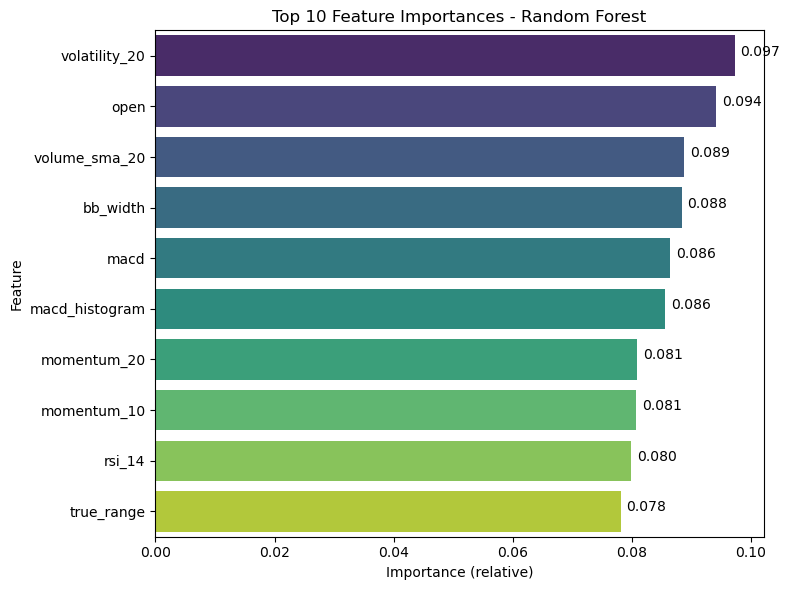

In [118]:
# Visualize top features
top_features = feature_importances.head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    x="importance",
    y="feature",
    data=top_features,
    palette="viridis"
)
for index, value in enumerate(top_features['importance']):
    plt.text(value + 0.001, index, f"{value:.3f}")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance (relative)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### The most important feature is volatility_20 at 9.7% of the model’s decision-making among the top 10 features.

### Shap

In [147]:
# Load model
with open("../models/random_forest_model.pkl", "rb") as f:
    model = pickle.load(f)

# Load test set
X_test = pd.read_csv("../Data/modeling_dataset_test_processed.csv")
X_test = X_test.apply(pd.to_numeric, errors='coerce')

X_test = X_test.fillna(X_test.mean())

# Convert to NumPy
X_test_array = X_test.values

 # Use TreeExplainer on the actual model
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_transformed)

# Check if model is a pipeline
# if isinstance(model, Pipeline):
    # Separate preprocessing and final estimator
    # preprocessing = model[:-1]  # all steps except last
    # final_model = model.named_steps[list(model.named_steps.keys())[-1]]  # last step

    # Transform test data
    #X_test_transformed = preprocessing.transform(X_test_array)

    # Use TreeExplainer on the actual model
    #explainer = shap.TreeExplainer(final_model)
    #shap_values = explainer.shap_values(X_test_transformed)

#else:
    # If standalone RandomForestClassifier
    #final_model = model
    #explainer = shap.TreeExplainer(final_model)
    #shap_values = explainer.shap_values(X_test_array)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()